# Пишем CatBoost своими руками: Шаги Ньютона и L2-Scoring

В этом ноутбуке мы заглянем «под капот» градиентного бустинга. Мы напишем с нуля кастомный движок на Python, который математически точно повторяет логику оригинального C++ движка CatBoost.

**Мы разберем:**
* Вычисление **L2-score и Cosine** для поиска оптимальных сплитов.
* Выполнение **шага Ньютона (Newton leaf estimation)** для обновления вероятностей.

In [1]:
!pip install catboost -q

import os
import io
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings('ignore')

# Для пользователей Windows с проблемами отрисовки деревьев Graphviz раскомментируйте строку ниже и укажите свой путь:
# os.environ["PATH"] += os.pathsep + r'C:\Users\YourName\Graphviz\bin'

## 1. Кастомный движок бустинга

Здесь собраны основные функции: поиск масок листьев, расчет наилучшего сплита на основе максимизации `L2-score` или `Cosine` и обновление вероятностей по формуле `Newton leaf estimation`.

Мы также написали универсальную функцию `parse_borders` для извлечения границ квантизации напрямую из файла CatBoost. Чтобы не дублировать код, мы собрали логику в функцию `fit_custom_catboost`.

In [2]:
def fit_custom_catboost(df, features, target, borders_dict, iterations, depth, learning_rate, l2_reg, score_function='L2', verbose=True, drawing_mode=False):
    """
    Главная функция для обучения кастомной модели градиентного бустинга.

    Алгоритм последовательно строит деревья решений. Каждое новое дерево
    пытается исправить ошибки, которые допустили все предыдущие деревья.

    Аргументы:
        df (pandas.DataFrame): Обучающий набор данных (таблица).
        features (list): Список названий признаков (колонок), по которым мы строим правила.
        target (str): Название целевой переменной (колонки, которую нужно предсказать).
        borders_dict (dict): Словарь с границами (порогами) для разделения значений признаков.
        iterations (int): Количество деревьев для построения (эпохи / шаги алгоритма).
        depth (int): Максимальная глубина каждого дерева (сколько в нем может быть уровней).
        learning_rate (float): Скорость обучения. Чем меньше шаг, тем аккуратнее учится модель.
        l2_reg (float): Коэффициент L2-регуляризации (штраф, который спасает от переобучения).
        score_function (str): Функция оценки качества разбиения ('L2' или 'Cosine').
        verbose (bool): Выводить ли текстовую информацию о процессе обучения на экран.
        drawing_mode (bool): Если True, функция вернет не только предсказания, но и все деревья.
    """
    # Делаем копию исходных данных, чтобы случайно их не модифицировать
    df = df.copy()

    # Сохраняем заданные стартовые вероятности (baseline) для взлома гессианов (используется один раз в статье для эксперимента)
    # Если предсказаний еще нет, начинаем с вероятности 50% (0.5) для всех строк (модель еще ничего не знает)
    if 'pred_prob' not in df.columns:
        df['pred_prob'] = 0.5

    # Здесь будем хранить структуру (правила) всех построенных деревьев
    all_trees = []

    # Главный цикл обучения: строим деревья одно за другим
    for i in range(iterations):
        if verbose:
            print(f"\n{'='*60}\nTree {i+1}\n{'='*60}")

        # Градиент (gradient) — это направление и величина ошибки: насколько реальный ответ отличается от нашего предсказания
        df['gradient'] = df[target] - df['pred_prob']

        # Гессиан (hessian) — это вторая производная (уверенность в предсказании).
        # Для задачи предсказания вероятностей он считается как: вероятность * (1 - вероятность)
        df['hessian'] = df['pred_prob'] * (1 - df['pred_prob'])

        # Список для хранения правил (сплитов) текущего дерева
        tree = []

        # Строим дерево уровень за уровнем до достижения максимальной глубины (depth)
        for d in range(depth):
            # 🌟 ПРОКИДЫВАЕМ score_function ВОТ СЮДА:
            # Ищем лучшее правило (сплит), чтобы оптимально разбить данные на 2 части
            best_split = find_best_split(df, tree, features, borders_dict, l2_reg, score_function)

            # Если мы не нашли хорошего разделения, которое бы улучшило качество, прекращаем растить это дерево
            if best_split is None:
                if verbose:
                    print(f"  [✂️ CROPPED] Остановлено на глубине {d} (нет сплитов, улучшающих {score_function}-score)")
                break

            # Добавляем найденный лучший сплит в структуру нашего дерева
            tree.append(best_split)

        # Выводим структуру построенного дерева на экран
        if verbose:
            print("  Structure:")
            if not tree:
                print("    [Empty Tree]")
            for lvl, (f, v) in enumerate(tree):
                # Печатаем каждое правило: уровень, признак и пороговое значение
                print(f"    Level {lvl+1}: {f} <= {v}")
            print("\n  Leaves Applied:")

        # Обновляем наши предсказания в датасете с учетом нового построенного дерева
        df['pred_prob'] = update_predictions(df, tree, learning_rate, l2_reg, verbose)
        all_trees.append(tree)

    # Возвращаем результаты в зависимости от флага drawing_mode
    if drawing_mode:
        return df['pred_prob'], all_trees
    else:
        return df['pred_prob']

def calculate_score(df, masks_list, score_function, l2_reg):
    """
    Вычисляет математическую оценку (score) качества для предложенного разбиения данных на листья.
    Чем больше score, тем лучше данное разбиение помогает отличить классы друг от друга.

    Аргументы:
        df (pandas.DataFrame): Таблица с данными, где посчитаны ошибки ('gradient').
        masks_list (list): Список фильтров (масок). Каждый фильтр показывает, какие строки попали в конкретный лист.
        score_function (str): Название функции для оценки ('L2' или 'Cosine').
        l2_reg (float): Коэффициент L2-регуляризации (штраф, который спасает от переобучения).
    """
    # 🌟 ВНУТРЕННЯЯ ФУНКЦИЯ ДЛЯ РАСЧЕТА СКОРА ДЕРЕВА
    total_num = 0     # Числитель (совпадает с итоговым результатом для функции L2)
    total_den_sq = 0  # Знаменатель под корнем (используется только для Cosine метрики)
    tmp_debug = []    # Промежуточный список для отладки

    # Проверяем каждый лист (каждую маску), который образовался при разбиении данных
    for mask in masks_list:
        w = mask.sum()  # Количество объектов (вес) в этом листе. Сумма значений True.

        # Если в лист попали хоть какие-то данные
        if w > 0:
            # Суммируем градиенты (ошибки) всех строк, оказавшихся в этом листе
            sum_grad = df.loc[mask, 'gradient'].sum()

            # a_leaf - потенциальное (кандидатное) значение (ответ), которое дерево выдаст в листе.
            # Формула: сумма градиентов / (количество объектов + L2 регуляризация).
            # (Переменная l2_reg захватывается из функции выше)
            a_leaf = sum_grad / (w + l2_reg)

            # Числитель: sum(w_i * a_i * g_i). Отражает полезность и вклад данного листа.
            total_num += a_leaf * sum_grad

            # Знаменатель: sum(w_i * a_i^2). Накапливается для расчета косинусного сходства.
            total_den_sq += w * (a_leaf ** 2)
            tmp_debug.append([w, a_leaf, w * (a_leaf ** 2)])

    # Возвращаем итоговую оценку в зависимости от выбранного метода
    if score_function == 'Cosine':
        # Нормализация на корень из знаменателя (константу sum(g^2) отбрасываем)
        return total_num / np.sqrt(total_den_sq) if total_den_sq > 0 else 0
    else:  # L2
        return total_num

def find_best_split(df, tree, features, borders_dict, l2_reg, score_function='L2'):
    """
    Ищет лучший признак и границу для нового разделения (сплита) данных
    с поддержкой L2 и Cosine score functions.

    Функция перебирает все доступные варианты и выбирает тот, который даст
    максимальный прирост качества прогноза.
    """
    # Получаем информацию, в каких листьях сейчас находятся строки до нового сплита
    leaf_masks_dict = get_leaves_masks(df, tree)

    # 1. Считаем скор текущего дерева (ДО нового сплита), это будет нашей "базой" для сравнения
    current_score = calculate_score(df, leaf_masks_dict.values(), score_function, l2_reg)

    # Минимальный порог, который мы хотим побить. Добавляем крошечное число (1e-9),
    # чтобы делать разбиение только в случае хотя бы минимального реального улучшения
    best_score = current_score + 1e-9
    best_split = None

    # 2. Перебираем все признаки по очереди
    for feat_idx, feature in enumerate(features):
        # Если для этого признака нет заранее подготовленных границ - пропускаем
        if feat_idx not in borders_dict:
            continue

        borders = borders_dict[feat_idx]

        # Перебираем каждый возможный порог для текущего признака
        for border in borders:
            # Создаем фильтр для левой ветки: значения меньше порога или пустые (NaN) уходят влево
            is_left = (df[feature] <= border) | df[feature].isna()

            # Если все данные ушли только в одну сторону (разделения не произошло), пропускаем этот вариант
            if is_left.sum() == 0 or (~is_left).sum() == 0:
                continue

            # Собираем список новых масок (листьев) после гипотетического разделения
            new_masks = []
            for mask in leaf_masks_dict.values():
                # Разрезаем каждый старый лист дерева на два новых: левый и правый
                new_masks.append(mask & is_left)
                new_masks.append(mask & (~is_left))

            # Считаем скор для всего дерева-кандидата с этим новым сплитом
            total_score = calculate_score(df, new_masks, score_function, l2_reg)

            # Если этот вариант оказался лучше всех предыдущих, запоминаем его как лучший
            if total_score > best_score:
                best_score = total_score
                best_split = (feature, border)

    return best_split

def parse_borders(filepath):
    """
    Парсит (читает) текстовый файл с границами квантизации CatBoost в словарь.

    Квантизация — это подход, при котором мы не перебираем все уникальные значения признака
    (например, каждую возможную зарплату), а разбиваем их на небольшое число порогов (корзин).
    Это значительно ускоряет обучение.
    """
    borders_dict = {}

    with open(filepath, 'r') as f:
        # Читаем файл строчка за строчкой
        for line in f:
            # Разбиваем строку на части по знаку табуляции
            parts = line.strip().split('\t')

            # Если в строке есть и номер признака, и значение порога
            if len(parts) >= 2:
                feat_idx = int(parts[0])      # Индекс (номер) признака
                border_val = float(parts[1])  # Значение порога (границы)

                # Если такого признака еще не было в словаре, создаем для него пустой список
                if feat_idx not in borders_dict:
                    borders_dict[feat_idx] = []

                # Сохраняем порог в список нужного признака
                borders_dict[feat_idx].append(border_val)

    return borders_dict

def get_leaves_masks(df, tree):
    """
    Возвращает логические маски строк (True/False массивы) для каждого листа дерева.

    Функция пропускает исходные данные через все условия построенного дерева
    и определяет, какие именно строки попали в каждый из финальных листьев.
    """
    # Если дерево еще пустое (правил нет), все данные находятся в одном большом корневом листе
    if not tree:
        return {"Root (All Data)": pd.Series(True, index=df.index)}

    # Вначале у нас одна ветка без правил, в которой лежат все строки (маска состоит из True)
    list_of_branches = [([], pd.Series(True, index=df.index))]

    # Проходим по каждому правилу разделения (уровню) дерева сверху вниз
    for column_to_check, split_value in tree:
        new_cut_pieces = []

        # Применяем новое правило к каждой существующей ветке
        for current_rules, current_mask in list_of_branches:

            # Логика для левой ветки: условие выполнилось (значение меньше или равно порогу)
            is_left_side = (df[column_to_check] <= split_value)
            left_mask = current_mask & is_left_side
            new_cut_pieces.append((current_rules + [f"{column_to_check}<={split_value:.3f}"], left_mask))

            # Логика для правой ветки: условие не выполнилось (значение строго больше порога)
            is_right_side = (df[column_to_check] > split_value)
            right_mask = current_mask & is_right_side
            new_cut_pieces.append((current_rules + [f"{column_to_check}>{split_value:.3f}"], right_mask))

        # Заменяем старые ветки на новые (уже разрезанные пополам) для следующего шага
        list_of_branches = new_cut_pieces

    # Объединяем правила через символ " & " (И), чтобы получить понятное текстовое название каждого листа
    return {" & ".join(rules): mask for rules, mask in list_of_branches}


def update_predictions(df, tree, lr, l2_reg, verbose=True):
    """
    Вычисляет значение в листе с помощью шага Ньютона и обновляет общие предсказания модели.

    Алгоритм высчитывает, какое значение (ответ) должен выдать каждый лист построенного дерева,
    и обновляет общие вероятности (логарифмические шансы) для всех объектов.
    """
    # Получаем информацию о том, в какие листья попали наши строки
    leaf_masks_dict = get_leaves_masks(df, tree)

    # Создаем пустую колонку для записи новых вычисленных вероятностей
    new_probs = pd.Series(index=df.index, dtype=float)

    # Проходимся по каждому листу дерева по очереди
    for leaf_name, mask in leaf_masks_dict.items():
        # Если в этот лист не попало ни одного объекта - идем к следующему
        if not mask.any():
            continue

        # Считаем сумму градиентов (ошибок) и сумму гессианов ("уверенности") для строк в этом листе
        sum_grad = df.loc[mask, 'gradient'].sum()
        sum_hess = df.loc[mask, 'hessian'].sum()

        # Формула шага Ньютона для расчета ответа в листе.
        # Мы делим ошибки на "уверенность" + L2-регуляризация (чтобы не было деления на ноль).
        # Умножаем на lr (скорость обучения), чтобы двигаться к цели постепенно и избежать переобучения.
        leaf_value = (sum_grad / (sum_hess + l2_reg)) * lr

        if verbose:
            print(f"    Leaf Value: {leaf_value:>7.4f} | Rows: {mask.sum():>4} | Filters: [{leaf_name}]")

        # Берем старые предсказанные вероятности для объектов из этого листа
        p = df.loc[mask, 'pred_prob']

        # Клиппинг: обрезаем вероятности совсем чуть-чуть, чтобы они не равнялись строго 0.0 или 1.0.
        # Иначе математическая функция логарифма ниже выдаст ошибку (логарифм от 0 не существует).
        p_safe = np.clip(p, 1e-15, 1 - 1e-15)

        # Переводим вероятности (от 0 до 1) в "лог-шансы" (пространство от минус бесконечности до плюс бесконечности).
        # К полученным лог-шансам безопасно прибавляем ответ нашего нового дерева (leaf_value).
        new_log_odds = np.log(p_safe / (1 - p_safe)) + leaf_value

        # Переводим обновленные "лог-шансы" обратно в нормальные вероятности через функцию сигмоиды
        new_probs.loc[mask] = 1 / (1 + np.exp(-new_log_odds))

    # Возвращаем обновленную колонку с предсказаниями для всего датасета
    return new_probs

## 2. Разбираем математику на простых данных (Toy Dataset)

Сгенерируем датасет с кредитными рисками, чтобы посмотреть, как алгоритм выбирает сплиты и считает значения листьев на наглядном примере. Для визуализации добавим график.

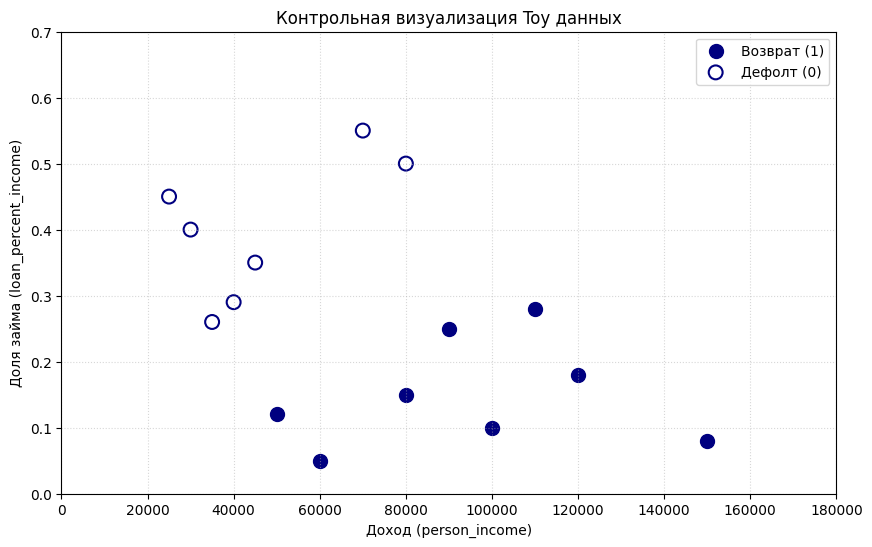

In [3]:
df_toy = pd.DataFrame({
    'person_income':       [100000, 80000, 60000, 120000, 50000, 150000,  30000, 45000, 80000, 25000, 70000,   90000, 110000,  35000, 40000],
    'loan_percent_income': [  0.10,  0.15,  0.05,   0.18,  0.12,   0.08,   0.40,  0.35,  0.50,  0.45,  0.55,    0.25,   0.28,   0.26,  0.29],
    'person_age':          [    25,    42,    55,     30,    48,     41,     22,    38,    60,    28,    33,      45,     24,     50,    35],
    'loan_status':         [     1,     1,     1,      1,     1,      1,      0,     0,     0,     0,     0,       1,      1,      0,     0]
})
target_toy = 'loan_status'
features_toy = ['loan_percent_income', 'person_income']

plt.figure(figsize=(10, 6))
status_1 = df_toy[df_toy['loan_status'] == 1]
status_0 = df_toy[df_toy['loan_status'] == 0]

plt.scatter(status_1['person_income'], status_1['loan_percent_income'],
            color='navy', marker='o', s=100, label='Возврат (1)')
plt.scatter(status_0['person_income'], status_0['loan_percent_income'],
            facecolors='none', edgecolors='navy', marker='o', s=100, linewidths=1.5, label='Дефолт (0)')

plt.xlim(0, 180000)
plt.ylim(0, 0.7)
plt.xlabel('Доход (person_income)')
plt.ylabel('Доля займа (loan_percent_income)')
plt.title('Контрольная визуализация Toy данных')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

## 3. Обучаем обычную Catboost модель

In [4]:
# Зададим параметры
cb_params_toy = {
  'iterations': 2,
  'depth': 4,
  'learning_rate': 0.8,
  'random_seed': 1,
  'reg_lambda': 3.0,
  'bootstrap_type': 'No',
  'penalties_coefficient': 0,
  'langevin': False,
  'diffusion_temperature': 0,
  'random_strength': 0,
  'logging_level': 'Silent',
  'score_function': 'Cosine',
  'leaf_estimation_method': 'Newton'
}

In [5]:
pool_toy = Pool(df_toy[features_toy], df_toy[target_toy])
pool_toy.quantize()
pool_toy.save_quantization_borders('border_toy.txt')
borders_dict_toy = parse_borders('border_toy.txt')


print("⏳ Обучение оригинального CatBoost...")
log_buffer = io.StringIO()
model_toy = CatBoostClassifier(**cb_params_toy).fit(pool_toy,log_cout=log_buffer,logging_level='Debug')
l2_reg_toy = model_toy.get_all_params()['l2_leaf_reg']

⏳ Обучение оригинального CatBoost...


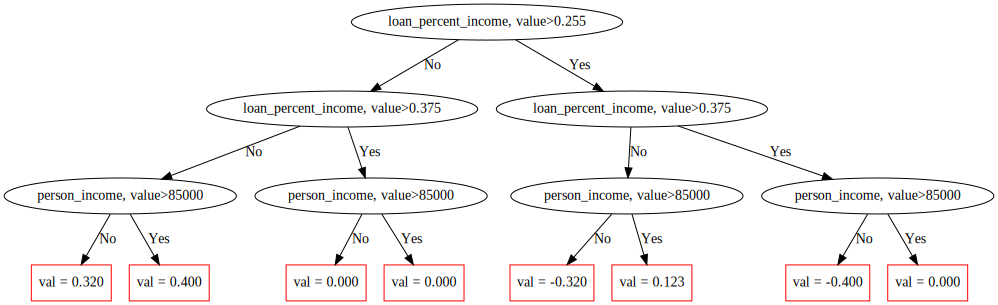

In [6]:
model_toy.plot_tree(
    tree_idx=0,
    pool=pool_toy
)

In [7]:
print(log_buffer.getvalue())

Features checksum calculation time: 0.0003637394417
Create new LearnProgress
Fold: Use owned online single ctrs
Fold: Use owned online single ctrs
Mem usage: Before start train: 325996544

loan_percent_income, bin=6 score 1.695285187
person_income, bin=8 score 1.896735143
loan_percent_income, bin=10 score 1.9139964
loan_percent_income, bin=6 score 1.9139964
  tensor 0 is redundant, remove it and stop
0:	learn: 0.5341393	total: 1.86ms	remaining: 1.86ms

loan_percent_income, bin=8 score 1.391268638
person_income, bin=3 score 1.557835675
loan_percent_income, bin=3 score 1.582888584
person_income, bin=3 score 1.582888584
  tensor 1 is redundant, remove it and stop
1:	learn: 0.4241715	total: 1.99ms	remaining: 0us



In [8]:
df_toy['Catboost_pred']=model_toy.predict_proba(pool_toy)[:, 1]

In [9]:
df_toy

,person_income,loan_percent_income,person_age,loan_status,Catboost_pred
0,100000,0.10,25,1,0.675124
1,80000,0.15,42,1,0.659438
2,60000,0.05,55,1,0.657338
3,120000,0.18,30,1,0.677169
4,50000,0.12,48,1,0.657338
5,150000,0.08,41,1,0.675124
6,30000,0.40,22,0,0.340116
7,45000,0.35,38,0,0.358294
8,80000,0.50,60,0,0.340116
9,25000,0.45,28,0,0.340116


## 4. Обучаем Catboost модель своим кодом

In [10]:
pool_toy = Pool(df_toy[features_toy], df_toy[target_toy])
pool_toy.quantize()
pool_toy.save_quantization_borders('border_toy.txt')
borders_dict_toy = parse_borders('border_toy.txt')

print("⏳ Обучение оригинального CatBoost...")
model_toy = CatBoostClassifier(**cb_params_toy).fit(pool_toy)
l2_reg_toy = model_toy.get_all_params()['l2_leaf_reg']

print("\n🚀 Запуск ручной реализации (Toy Dataset)...")
custom_pred_toy = fit_custom_catboost(
    df_toy, features_toy, target_toy, borders_dict_toy,
    cb_params_toy['iterations'], cb_params_toy['depth'],
    cb_params_toy['learning_rate'], l2_reg_toy,score_function=cb_params_toy['score_function']
)

cb_pred_toy = model_toy.predict_proba(pool_toy)[:, 1]
max_diff_toy = (cb_pred_toy - custom_pred_toy).abs().max()

print("\n" + "="*80)
print(f"🎯 Максимальная разница вероятностей (Toy): {max_diff_toy:.12f}")
if max_diff_toy < 1e-7:
    print("✅ SUCCESS! Идеальное математическое совпадение.")
else:
    print("❌ Найдены расхождения.")
print("="*80)

⏳ Обучение оригинального CatBoost...

🚀 Запуск ручной реализации (Toy Dataset)...

Tree 1
  [✂️ CROPPED] Остановлено на глубине 3 (нет сплитов, улучшающих Cosine-score)
  Structure:
    Level 1: loan_percent_income <= 0.2549999952
    Level 2: person_income <= 85000.0
    Level 3: loan_percent_income <= 0.375

  Leaves Applied:
    Leaf Value:  0.3200 | Rows:    3 | Filters: [loan_percent_income<=0.255 & person_income<=85000.000 & loan_percent_income<=0.375]
    Leaf Value:  0.4000 | Rows:    4 | Filters: [loan_percent_income<=0.255 & person_income>85000.000 & loan_percent_income<=0.375]
    Leaf Value: -0.3200 | Rows:    3 | Filters: [loan_percent_income>0.255 & person_income<=85000.000 & loan_percent_income<=0.375]
    Leaf Value: -0.4000 | Rows:    4 | Filters: [loan_percent_income>0.255 & person_income<=85000.000 & loan_percent_income>0.375]
    Leaf Value:  0.1231 | Rows:    1 | Filters: [loan_percent_income>0.255 & person_income>85000.000 & loan_percent_income<=0.375]

Tree 2
  [

In [11]:
df_toy['pred']=cb_pred_toy
df_toy

,person_income,loan_percent_income,person_age,loan_status,Catboost_pred,pred
0,100000,0.10,25,1,0.675124,0.675124
1,80000,0.15,42,1,0.659438,0.659438
2,60000,0.05,55,1,0.657338,0.657338
3,120000,0.18,30,1,0.677169,0.677169
4,50000,0.12,48,1,0.657338,0.657338
5,150000,0.08,41,1,0.675124,0.675124
6,30000,0.40,22,0,0.340116,0.340116
7,45000,0.35,38,0,0.358294,0.358294
8,80000,0.50,60,0,0.340116,0.340116
9,25000,0.45,28,0,0.340116,0.340116


## 5. Боевое тестирование на Titanic (Трюк с NaN)

На реальных датасетах часто встречаются пропуски (`NaN`). По умолчанию CatBoost использует стратегию обработки пропусков `nan_mode='Min'`, что означает, что при квантизации и поиске сплитов алгоритм отправляет все `NaN` в самое левое поддерево (считает их меньше любого другого значения).

Чтобы сымитировать это поведение на уровне чистой математики (Pandas/Numpy), мы заполним пропуски экстремально маленьким числом `-999`. Это элегантный хак, который позволяет нашему кастомному движку без изменения логики сплитов обрабатывать `NaN` точно так же, как это делает C++ движок CatBoost.

In [12]:
print("⏳ Загрузка датасета Titanic...")
try:
    df_raw = sns.load_dataset('titanic')
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df_raw = pd.read_csv(url)
    df_raw.columns = [c.lower() for c in df_raw.columns]

features_tit = ['pclass', 'age', 'sibsp', 'parch', 'fare']
target_tit = 'survived'
df_titanic = df_raw[features_tit + [target_tit]].copy()

# ХАК: Заменяем пропуски на -999, чтобы эмулировать логику nan_mode='Min'
df_titanic = df_titanic.fillna(-999)
print(f"Размер датасета: {df_titanic.shape[0]} строк. Все пропуски заменены на -999.\n")

cb_params_tit = {
  'iterations': 10,
  'depth': 6,
  'learning_rate': 0.5,
  'random_seed': 42,
  'reg_lambda': 3.0,
  'bootstrap_type': 'No',
  'penalties_coefficient': 0,
  'langevin': False,
  'diffusion_temperature': 0,
  'random_strength': 0,
  'logging_level': 'Silent',
  'score_function': 'Cosine',
  'leaf_estimation_method': 'Newton'
}



print("⏳ Квантизация признаков...")
pool_tit = Pool(df_titanic[features_tit], df_titanic[target_tit])
pool_tit.quantize()
pool_tit.save_quantization_borders('titanic_borders.txt')
borders_dict_tit = parse_borders('titanic_borders.txt')

print("⏳ Обучение оригинального CatBoost...")
model_tit = CatBoostClassifier(**cb_params_tit).fit(pool_tit)
l2_reg_tit = model_tit.get_all_params()['l2_leaf_reg']
cb_pred_tit = model_tit.predict_proba(pool_tit)[:, 1]

print("🚀 Запуск ручной реализации (Custom Engine)...")
custom_pred_tit = fit_custom_catboost(
    df_titanic, features_tit, target_tit, borders_dict_tit,
    cb_params_tit['iterations'], cb_params_tit['depth'],
    cb_params_tit['learning_rate'], l2_reg_tit,cb_params_tit['score_function'],
    verbose=False  # Отключаем логи, чтобы не перегружать вывод
)


max_diff_tit = (cb_pred_tit - custom_pred_tit).abs().max()
print("\n" + "="*80)
print(f"🎯 Максимальная разница вероятностей (Titanic): {max_diff_tit:.12f}")
if max_diff_tit < 1e-7:
    print("✅ УСПЕХ! Математика идеальна! Реализация совпала с CatBoost на Титанике!")
else:
    print("❌ Найдены расхождения.")
print("="*80)

⏳ Загрузка датасета Titanic...
Размер датасета: 891 строк. Все пропуски заменены на -999.

⏳ Квантизация признаков...
⏳ Обучение оригинального CatBoost...
🚀 Запуск ручной реализации (Custom Engine)...

🎯 Максимальная разница вероятностей (Titanic): 0.000000000000
✅ УСПЕХ! Математика идеальна! Реализация совпала с CatBoost на Титанике!


# L2 Score VS Cosine взрыв гессианов

Функцию calculate_score для иллюстрации взрыва гессиана требуется изменить так как для того чтобы сходиться с Catboost мы использовали его оптимизацию где вместо гессианов для расчета Leaf value при расчете скоров подставляется число наблюдений в листе. Это число целое и не позволяет сделать знаменатель листа маленьким, поэтому вместо него подставим истинные гессианы для нашего эксперимента

Обратите внимание на этот кусок кода он самый важный в данном эксперименте
```python
# ВЗЛОМ ГЕССИАНОВ: Симулируем самоуверенную ошибку для выбросов
df_toy['pred_prob'] = 0.5
df_toy.iloc[-3:, df_toy.columns.get_loc('pred_prob')] = 0.001
```

In [13]:
def calculate_score(df,masks_list,score_function,l2_reg):
    # 🌟 ВНУТРЕННЯЯ ФУНКЦИЯ ДЛЯ РАСЧЕТА СКОРА ДЕРЕВА
        total_num = 0     # Числитель (совпадает с L2-score)
        total_den_sq = 0  # Знаменатель под корнем для Cosine
        for mask in masks_list:
            w = mask.sum() # Количество объектов (вес) в листе
            if w > 0:
                sum_grad = df.loc[mask, 'gradient'].sum()
                # ИСПРАВЛЕНИЕ: Считаем сумму гессианов (Шаг Ньютона)
                sum_hess = df.loc[mask, 'hessian'].sum()
                # a_leaf - потенциальное (кандидатное) значение в листе
                a_leaf = sum_grad / (sum_hess + l2_reg)

                # Числитель: sum(w_i * a_i * g_i)
                total_num += a_leaf * sum_grad

                # Знаменатель: sum(w_i * a_i^2)
                total_den_sq += w * (a_leaf ** 2)
        if score_function == 'Cosine':
            # Нормализация на корень из знаменателя (константу sum(g^2) отбрасываем)
            return total_num / np.sqrt(total_den_sq) if total_den_sq > 0 else 0
        else: # L2
            return total_num


def get_simple_borders(df, features):
    borders_dict = {}
    for i, feat in enumerate(features):
        vals = sorted(df[feat].dropna().unique())
        # Берем середины между всеми уникальными точками для идеальных разрезов
        borders = [(vals[j] + vals[j+1])/2 for j in range(len(vals)-1)]
        borders_dict[i] = borders
    return borders_dict

# ==========================================
# 2. ПОДГОТОВКА ДАННЫХ И ВЗЛОМ ГЕССИАНОВ
# ==========================================
np.random.seed(42)
N = 100

# Главные кластеры: идеально делятся по X1 (вертикально)
X_0 = np.random.normal(loc=[-1.0, 0.0], scale=[0.3, 1.0], size=(N, 2))
X_1 = np.random.normal(loc=[1.0, 0.0], scale=[0.3, 1.0], size=(N, 2))
y_0 = np.zeros(N)
y_1 = np.ones(N)

# Выбросы-ловушки (Класс 1, но заброшены высоко по X2)
X_out = np.array( [[-1.0, 5.0], [-1.1, 5.1], [-0.9, 4.9]])
y_out = np.array([1, 1, 1])

# Собираем датасет
df_toy = pd.DataFrame(np.vstack([X_0, X_1, X_out]), columns=['X1', 'X2'])
df_toy['target'] = np.concatenate([y_0, y_1, y_out])

# ВЗЛОМ ГЕССИАНОВ: Симулируем самоуверенную ошибку для выбросов
df_toy['pred_prob'] = 0.5
df_toy.iloc[-3:, df_toy.columns.get_loc('pred_prob')] = 0.001

features_toy = ['X1', 'X2']
borders_dict_toy = get_simple_borders(df_toy, features_toy)

#

# ==========================================
# 4. ВИЗУАЛИЗАЦИЯ
# ==========================================
def plot_split(ax, title, tree, df):
    ax.scatter(df[df['target']==0]['X1'], df[df['target']==0]['X2'], c='#3498db', edgecolors='k', label='Класс 0')
    ax.scatter(df[df['target']==1]['X1'][:-3], df[df['target']==1]['X2'][:-3], c='#e74c3c', edgecolors='k', label='Класс 1')

    # Выделяем выбросы
    ax.scatter(df[df['target']==1]['X1'][-3:], df[df['target']==1]['X2'][-3:],
               c='#f1c40f', s=250, marker='*', edgecolors='red', linewidths=1.5, label='Выбросы (Класс 1)')

    # Отрисовка линии сплита
    if tree and len(tree[0]) > 0:
        feature, value = tree[0][0]
        if feature == 'X1':
            ax.axvline(x=value, color='green', linestyle='--', linewidth=3, label=f'Сплит: {feature} <= {value:.2f}')
        else:
            ax.axhline(y=value, color='black', linestyle='--', linewidth=3, label=f'Сплит: {feature} <= {value:.2f}')

    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('Признак X1')
    ax.set_ylabel('Признак X2 (Шумовой)')
    ax.legend(loc='lower right')




Tree 1
  Structure:
    Level 1: X2 <= 4.376365745327361

  Leaves Applied:
    Leaf Value:  0.0000 | Rows:  200 | Filters: [X2<=4.376]
    Leaf Value: 749.8124 | Rows:    3 | Filters: [X2>4.376]

Tree 1
  Structure:
    Level 1: X1 <= -0.20326221582878135

  Leaves Applied:
    Leaf Value: -1.8798 | Rows:  103 | Filters: [X1<=-0.203]
    Leaf Value:  1.9999 | Rows:  100 | Filters: [X1>-0.203]


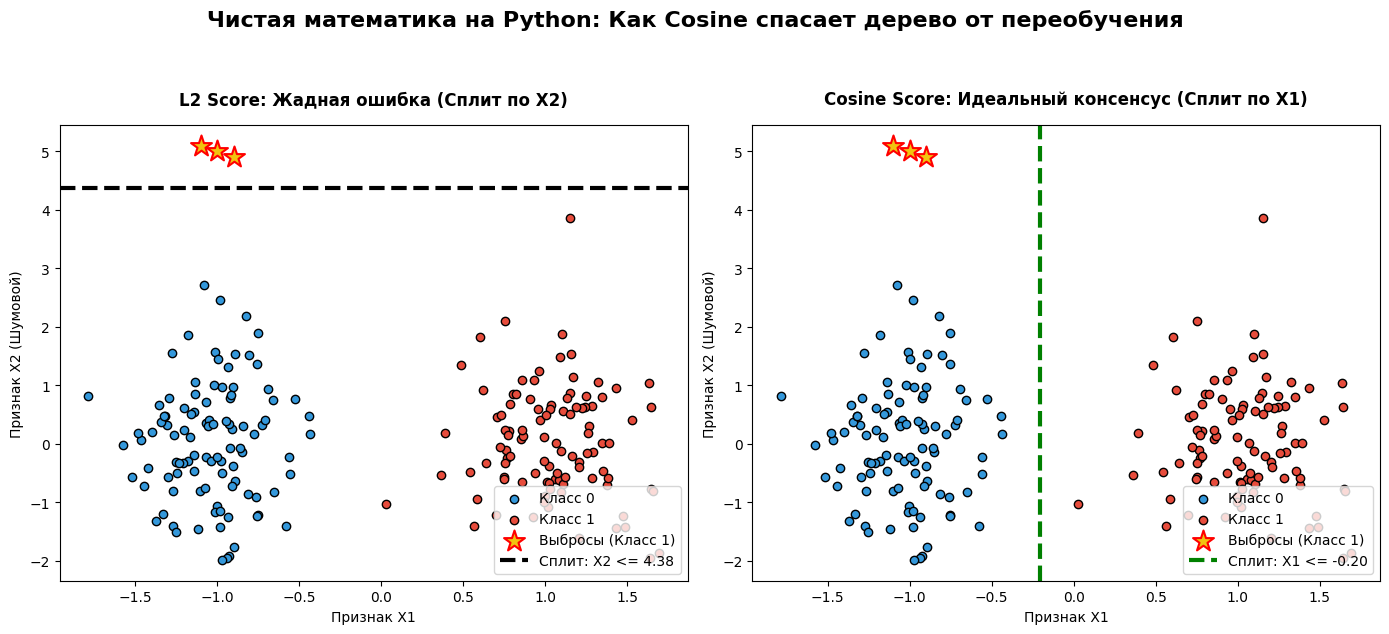

In [14]:
#Ослабляем регуляризатор, чтобы позволить дроби взорваться!
l2_reg_toy = 0.001

# ==========================================
# 3. ОБУЧЕНИЕ МОДЕЛЕЙ
# ==========================================
# Обучаем L2
_, trees_l2 = fit_custom_catboost(
    df_toy, features_toy, 'target', borders_dict_toy,
    iterations=1, depth=1, learning_rate=1.0, l2_reg=l2_reg_toy, score_function='L2', verbose=True,drawing_mode=True
)

# Обучаем Cosine
_, trees_cos = fit_custom_catboost(
    df_toy, features_toy, 'target', borders_dict_toy,
    iterations=1, depth=1, learning_rate=1.0, l2_reg=l2_reg_toy, score_function='Cosine', verbose=True,drawing_mode=True
)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plot_split(ax1, 'L2 Score: Жадная ошибка (Сплит по X2)', trees_l2, df_toy)
plot_split(ax2, 'Cosine Score: Идеальный консенсус (Сплит по X1)', trees_cos, df_toy)

plt.suptitle('Чистая математика на Python: Как Cosine спасает дерево от переобучения', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Как видно из картинки выше L2 функция скора из-за крайне низких значений гессианов сработала некорректно и отвелклась на те самые 3 выброса с низкими гессианами которые мы выше подставили вручную


Tree 1
  Structure:
    Level 1: X1 <= -0.20326221582878135

  Leaves Applied:
    Leaf Value: -1.8724 | Rows:  103 | Filters: [X1<=-0.203]
    Leaf Value:  1.9920 | Rows:  100 | Filters: [X1>-0.203]

Tree 1
  Structure:
    Level 1: X1 <= -0.20326221582878135

  Leaves Applied:
    Leaf Value: -1.8724 | Rows:  103 | Filters: [X1<=-0.203]
    Leaf Value:  1.9920 | Rows:  100 | Filters: [X1>-0.203]


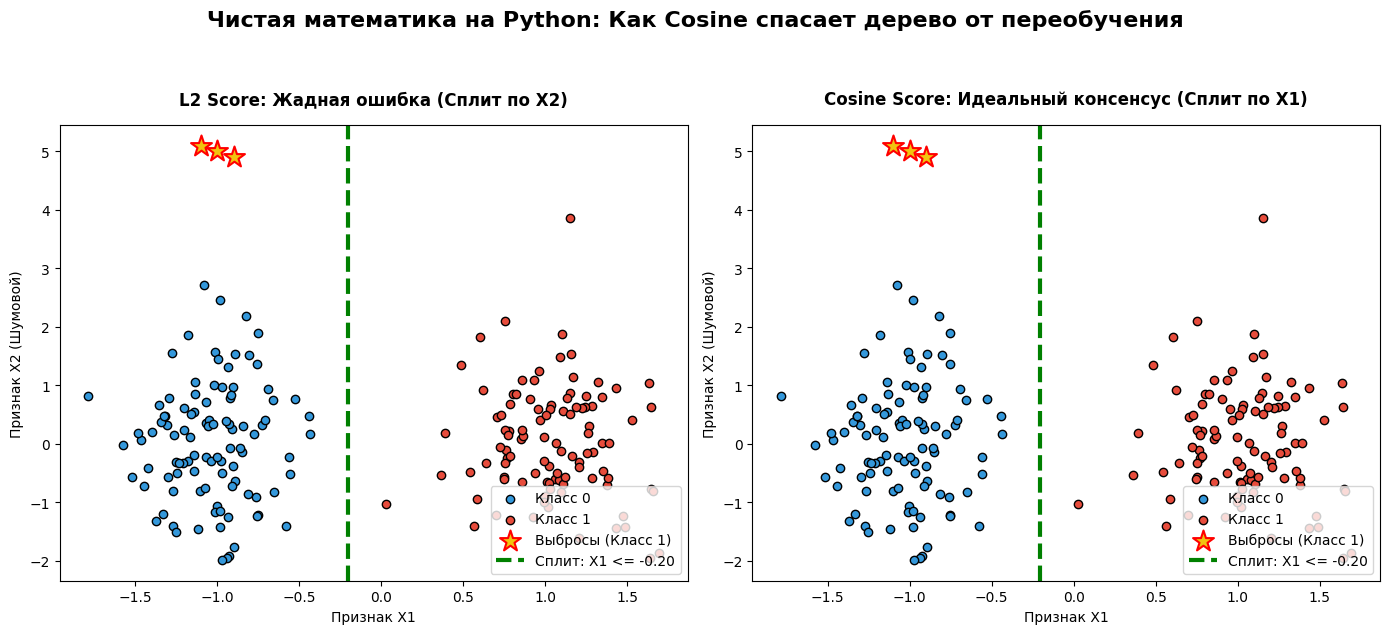

In [15]:
#Обычный регуляризатор защищает L2 score функцию
l2_reg_toy = 0.1

# ==========================================
# 3. ОБУЧЕНИЕ МОДЕЛЕЙ
# ==========================================
# Обучаем L2
_, trees_l2 = fit_custom_catboost(
    df_toy, features_toy, 'target', borders_dict_toy,
    iterations=1, depth=1, learning_rate=1.0, l2_reg=l2_reg_toy, score_function='L2', verbose=True,drawing_mode=True
)

# Обучаем Cosine
_, trees_cos = fit_custom_catboost(
    df_toy, features_toy, 'target', borders_dict_toy,
    iterations=1, depth=1, learning_rate=1.0, l2_reg=l2_reg_toy, score_function='Cosine', verbose=True,drawing_mode=True
)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plot_split(ax1, 'L2 Score: Жадная ошибка (Сплит по X2)', trees_l2, df_toy)
plot_split(ax2, 'Cosine Score: Идеальный консенсус (Сплит по X1)', trees_cos, df_toy)

plt.suptitle('Чистая математика на Python: Как Cosine спасает дерево от переобучения', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()